In [1]:
# Import necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
 
%matplotlib inline
sns.set_style('whitegrid')


In [2]:
# Read the dataset into a dataframe and print it's shape and column names
df = pd.read_csv('USA_Housing.csv')
print(df.shape)
print(df.columns.tolist())

(5000, 7)
['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address']


In [3]:
# Display the first five rows of the dataset
df.head()



,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [4]:
# Display a brief infomation of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   str    
dtypes: float64(6), str(1)
memory usage: 273.6 KB


In [5]:
# Diaplay a description of the dataset
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


In [6]:
# Check for missing values in the column
df.isnull().sum().sort_values(ascending=False)

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

In [7]:
# Drop the Address column
df = df.drop('Address', axis=1)
print(df.columns.tolist())

['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population', 'Price']


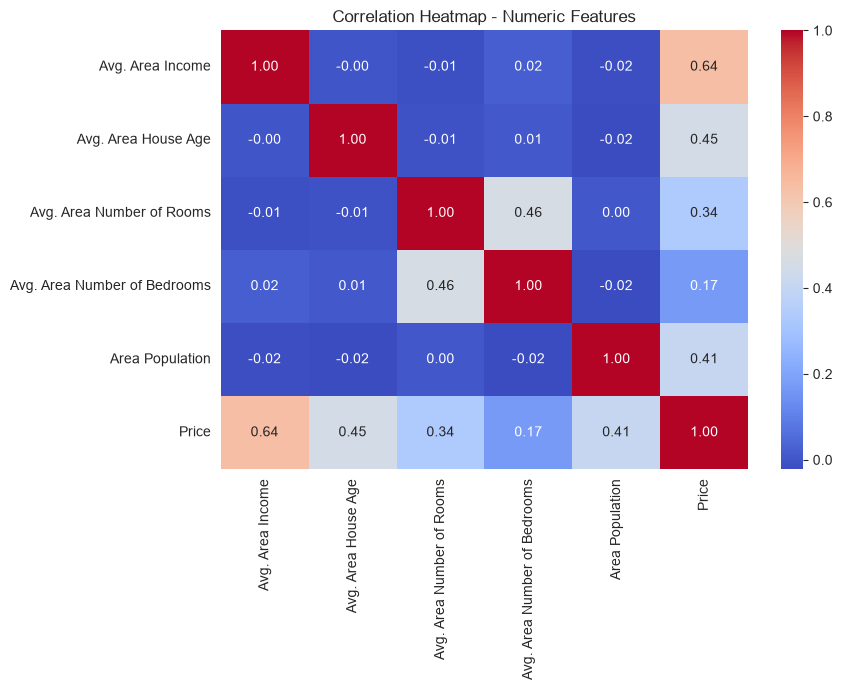

In [8]:
# Create a heatmap of the correlation between all numeric columns, including Price.
plt.figure(figsize=(9, 7))
numeric_df = df[['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population', 'Price']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Numeric Features')
plt.tight_layout()
plt.show()

# Observation
'Avg. Area Income has the strongest correlation with Price while Avg. Area Number of Bedrooms has the weakest. This suggest that Price and Avg. Area Income will matter most for prediction.

In [9]:
# Using Avg. Area Income to predict Price
X = df[['Avg. Area Income']]
y = df['Price']

In [ ]:
# Split the Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train size:', X_train.shape[0])
print('Test size:', X_test.shape[0])

Train size: 4000
Test size: 1000


In [11]:
# Create and fit a LinearRegression model on the training data.
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[21.21]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Avg. Area Income']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.251e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


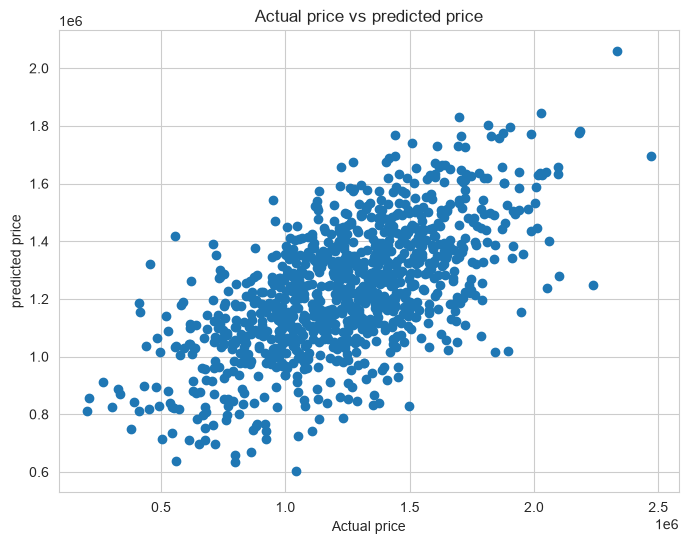

In [12]:
#  Predict on the test set, and plot actual vs. predicted values as a scatter plot.
y_pred_simple = model_simple.predict(X_test)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_simple)
plt.xlabel('Actual price')
plt.ylabel('predicted price')
plt.title('Actual price vs predicted price')
plt.show()

In [13]:
# Print the model's coefficient and intercept.
print('Coefficient:', model_simple.coef_[0])
print('Intercept:', model_simple.intercept_)


Coefficient: 21.208906292657513
Intercept: -225053.70287170145


# Explanation
The coefficient gives the slope of the graph.

# Observation
According to this model, for every $1 increase in average area income the predicted house price increase by $21.208906292657513.

In [14]:
# Select all numeric feature columns (everything except Price) as X, and Price as y.
X_multi = df.drop('Price', axis=1)
y_multi = df['Price']

In [15]:
# Split the Dataset
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)
print('Train size:', X_train_multi.shape[0])
print('Test size:', X_test_multi.shape[0])

Train size: 4000
Test size: 1000


In [ ]:
# Train the model
model_multi = LinearRegression()
model_multi.fit(X_train_multi, y_train_multi)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 21.65,164666.48,119624.01, 2440.38, 15.27]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Avg. Area Income','Avg. Area House Age','Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms','Area Population']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.635e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


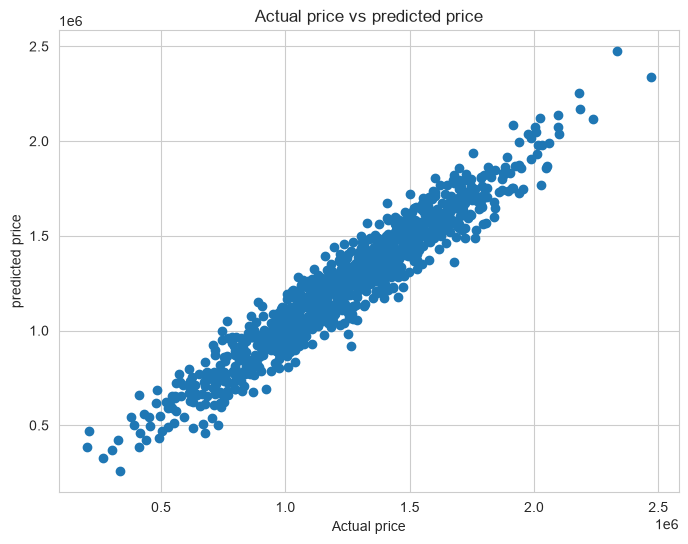

In [17]:
# Predict on the test set.
y_pred_multi = model_multi.predict(X_test_multi)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_multi)
plt.xlabel('Actual price')
plt.ylabel('predicted price')
plt.title('Actual price vs predicted price')
plt.show()

In [18]:
# Print the coefficient for each feature next to its column name.
coeff_df = pd.DataFrame(model_multi.coef_, X_multi.columns, columns=['Coefficient'])
print(coeff_df)

                                Coefficient
Avg. Area Income                  21.652206
Avg. Area House Age           164666.480722
Avg. Area Number of Rooms     119624.012232
Avg. Area Number of Bedrooms    2440.377611
Area Population                   15.270313


# EXPLANATION
Avg. Area House Age (164666.480722) has the greatest effect on price.

# OBSERVATION
Avg. Area House Age (164666.480722) has the largest coefficient, but it does not mean that it is the most important feature for predicting price. This is because the individual features have different scale, because of this the coefficient might be large due to the way it is measured.

In [19]:
# Calculate MAE, MSE, RMSE, and R² for the simple regression mode
mae_simple = metrics.mean_absolute_error(y_test, y_pred_simple)
mse_simple = metrics.mean_squared_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)
r2_simple = metrics.r2_score(y_test, y_pred_simple)
print('MAE:', mae_simple)
print('MSE:', mse_simple)
print('RMSE:', rmse_simple)
print('R2:', r2_simple)

MAE: 216826.35309989064
MSE: 74194887058.66
RMSE: 272387.38417676394
R2: 0.39694865192619766


In [20]:
# Calculate for the multiple regression model
mae_multi = metrics.mean_absolute_error(y_test_multi, y_pred_multi)
mse_multi = metrics.mean_squared_error(y_test_multi, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
r2_multi = metrics.r2_score(y_test_multi, y_pred_multi)
print('MAE:', mae_multi)
print('MSE:', mse_multi)
print('RMSE:', rmse_multi)
print('R2:', r2_multi)

MAE: 80879.09723489822
MSE: 10089009300.894522
RMSE: 100444.06055558746
R2: 0.9179971706834288


In [33]:
# Comparison the reggression metrics
comparison = pd.DataFrame({'Simple (Income only)': [mae_simple, mse_simple, rmse_simple, r2_simple],'Multiple (All features)': [mae_multi, mse_multi, rmse_multi, r2_multi]}, index=['MAE', 'MSE', 'RMSE', 'R2'])
print(comparison)

      Simple (Income only)  Multiple (All features)
MAE           2.168264e+05             8.087910e+04
MSE           7.419489e+10             1.008901e+10
RMSE          2.723874e+05             1.004441e+05
R2            3.969487e-01             9.179972e-01


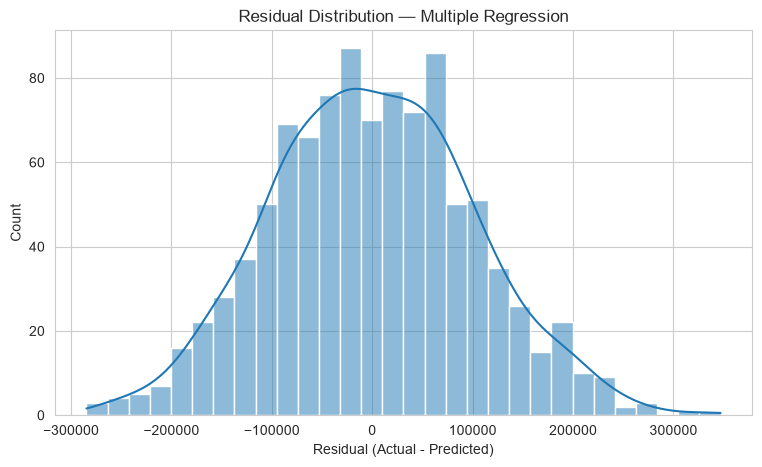

In [22]:
# Plot a histogram of the residuals
residuals = y_test_multi - y_pred_multi
plt.figure(figsize=(9, 5))
sns.histplot(residuals, bins=30, kde=True)
plt.title('Residual Distribution — Multiple Regression')
plt.xlabel('Residual (Actual - Predicted)')
plt.show()

# OBSERVATION
Which model performed better, and by how much?
The Multiple Linear Regression performed better by 0.52(52%) using the R² score.

Was adding more features worth it?
Yes, it was worth it, this is because it captured more information for the prediction of price.

What does the shape of the residual histogram tell you about the model's errors? 
The residual histogram is roughly bell shaped and centered around zero. The over-estimated and under-estimated values of price are fairly evenly distributed showing that the model is unbiased.
 


In [23]:
# Create degree-2 polynomial features.
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

In [25]:
# Using Avg. Area Income to predict Price
X_poly = df[['Avg. Area Income']]
y_poly = df['Price']

# Split the Dataset
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
    X_poly, y_poly, test_size=0.2, random_state=42)
print('Train size:', X_train_poly.shape[0])
print('Test size:', X_test_poly.shape[0])

Train size: 4000
Test size: 1000


In [26]:
# Train the model
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train_poly)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[21.21]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Avg. Area Income']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.251e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


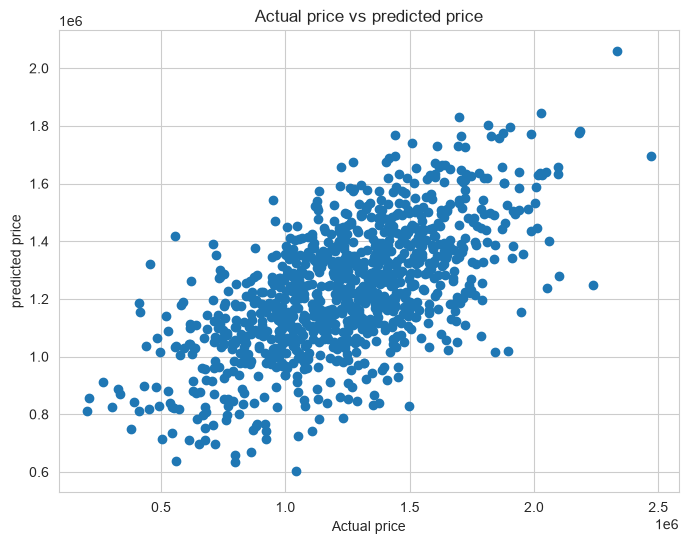

R2: 0.39694865192619766


In [31]:
# Predict on the test set.
y_pred_poly = model_poly.predict(X_test_poly)
plt.figure(figsize=(8, 6))
plt.scatter(y_test_poly, y_pred_poly)
plt.xlabel('Actual price')
plt.ylabel('predicted price')
plt.title('Actual price vs predicted price')
plt.show()

# Calculate R² score
r2_poly = metrics.r2_score(y_test_poly, y_pred_poly)
print('R2:', r2_poly)


In [30]:
# Comparison
comparison = pd.DataFrame({'Simple (Income only)': [r2_simple],'Polynomial (Income)': [r2_poly]}, index=['R2'])
print(comparison)

    Simple (Income only)  Polynomial (Income)
R2              0.396949             0.396949


# Answer
No, the polynomial regression did not improve the fit.

# Observation
For this feature, the polynomial regression did not improve the linear simple regression. this is because the the simple linear regression captures the dataset well